100%|██████████| 26.4M/26.4M [00:01<00:00, 18.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 303kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.58MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 2.60MB/s]


Visualizing hidden layer activations for sample images...


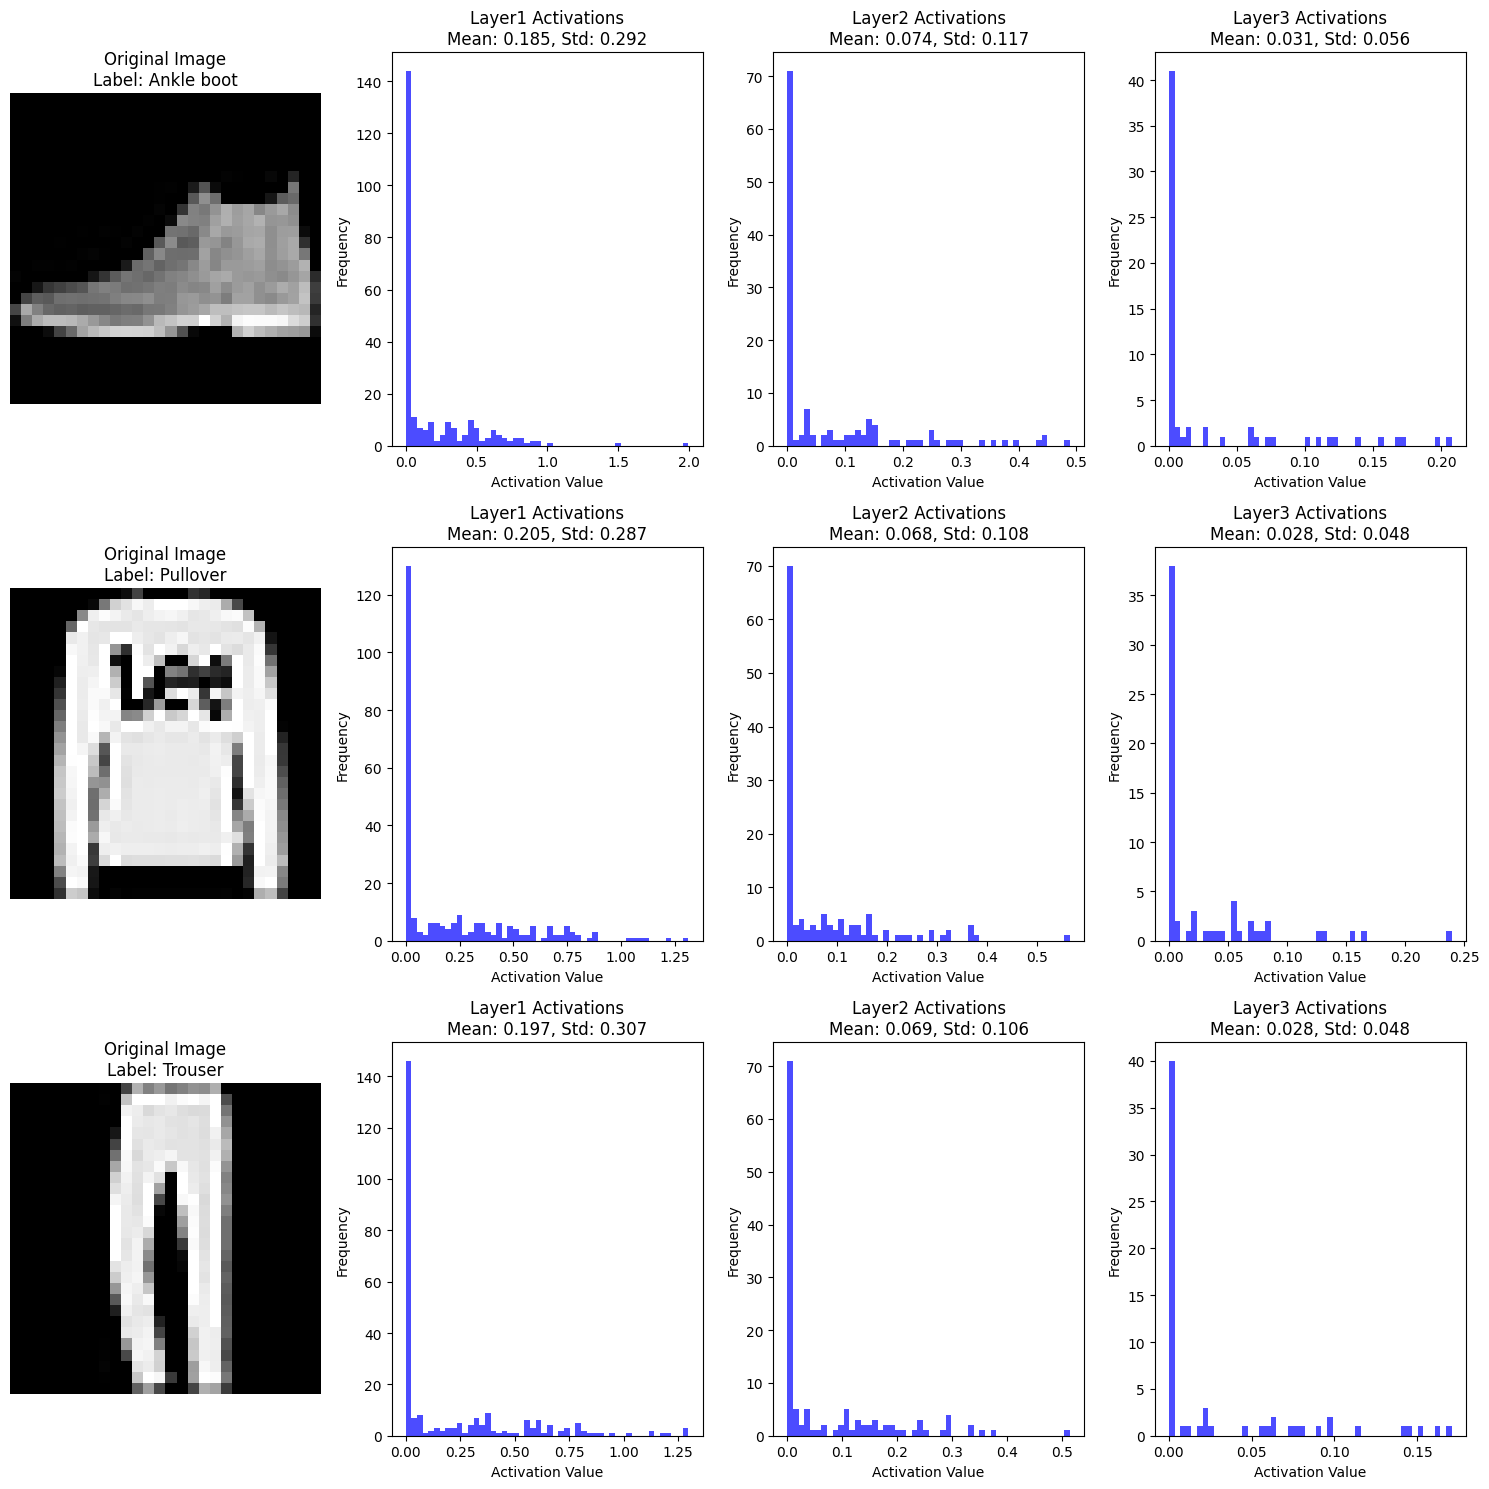


Activation distributions across all sample images:


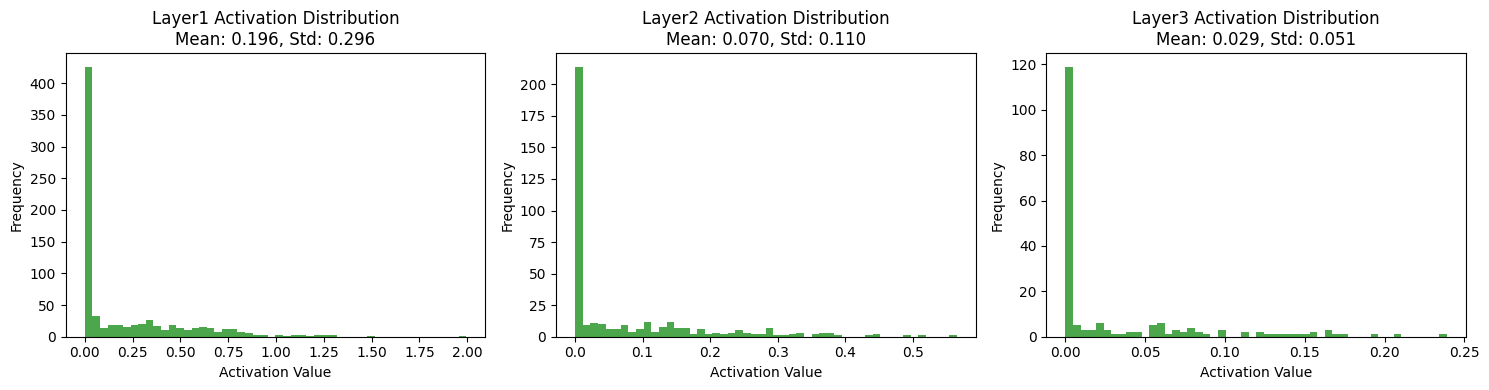


=== Explanation of Feature Transformation in Hidden Layers ===

1. Layer 1 (First Hidden Layer):
   - Activations represent low-level features extracted from the raw pixel inputs.
   - For image data, these might correspond to edges, corners, or simple textures.
   - The distribution often shows many near-zero values (due to ReLU) and some positive activations.

2. Layer 2 (Second Hidden Layer):
   - Activations combine features from Layer 1 to form more complex patterns.
   - These might represent parts of objects, such as sleeves of shirts, collars, or shoe shapes.
   - The distribution may show a different spread, often with higher mean activation as features become more specialized.

3. Layer 3 (Third Hidden Layer):
   - Activations represent high-level features that are combinations of previous layer features.
   - These correspond to complex patterns specific to object categories, like the overall shape of a bag or a boot.
   - The distribution often shows more sparse activation

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the trained model (assuming it's saved or we use the one from previous tasks)
# For this example, I'll create a model similar to what we used earlier
class FashionMNISTClassifier(nn.Module):
    def __init__(self, input_size=784, hidden_sizes=[256, 128, 64], num_classes=10):
        super(FashionMNISTClassifier, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_sizes[0])
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.relu2 = nn.ReLU()
        self.layer3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.relu3 = nn.ReLU()
        self.output = nn.Linear(hidden_sizes[2], num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        act1 = self.relu1(self.layer1(x))
        act2 = self.relu2(self.layer2(act1))
        act3 = self.relu3(self.layer3(act2))
        output = self.output(act3)
        return output, act1, act2, act3

# Initialize model and load weights if available, otherwise train briefly
model = FashionMNISTClassifier().to(device)
# For this demo, we'll assume the model is already trained; in practice, you should load a trained model

# Define transformations for the dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load FashionMNIST test dataset
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# Define class names for FashionMNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Get sample images from test dataset
def get_sample_images(num_samples=5):
    samples = []
    labels = []
    for i, (image, label) in enumerate(test_loader):
        if i >= num_samples:
            break
        samples.append(image)
        labels.append(label)
    return torch.cat(samples), torch.cat(labels)

sample_images, sample_labels = get_sample_images(3)
sample_images = sample_images.to(device)
sample_labels = sample_labels.to(device)

# Function to visualize activations
def visualize_activations(model, images, layer_names=['Layer1', 'Layer2', 'Layer3']):
    model.eval()
    with torch.no_grad():
        # Pass images through model to get activations
        outputs, act1, act2, act3 = model(images)

    activations = [act1, act2, act3]

    # Plot original images and activations for each layer
    fig, axes = plt.subplots(len(images), len(activations) + 1, figsize=(15, 5 * len(images)))

    if len(images) == 1:
        axes = axes.reshape(1, -1)

    for img_idx in range(len(images)):
        # Plot original image
        axes[img_idx, 0].imshow(images[img_idx].cpu().squeeze(), cmap='gray')
        axes[img_idx, 0].set_title(f'Original Image\nLabel: {class_names[sample_labels[img_idx]]}')
        axes[img_idx, 0].axis('off')

        # Plot activations for each layer
        for layer_idx, activation in enumerate(activations):
            act = activation[img_idx].cpu().numpy()

            # For visualization, we can plot the activation values as a histogram or as a sorted plot
            # Here I'll show a histogram of activation values
            axes[img_idx, layer_idx + 1].hist(act, bins=50, alpha=0.7, color='blue')
            axes[img_idx, layer_idx + 1].set_title(f'{layer_names[layer_idx]} Activations\nMean: {np.mean(act):.3f}, Std: {np.std(act):.3f}')
            axes[img_idx, layer_idx + 1].set_xlabel('Activation Value')
            axes[img_idx, layer_idx + 1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    return activations

# Visualize activations for sample images
print("Visualizing hidden layer activations for sample images...")
activations = visualize_activations(model, sample_images)

# Additional visualization: Show how activations change across layers for one image
def plot_activation_distribution(activations, layer_names):
    fig, axes = plt.subplots(1, len(activations), figsize=(15, 4))

    for i, (act, name) in enumerate(zip(activations, layer_names)):
        # Flatten all activations for this layer across all samples
        flat_act = act.cpu().numpy().flatten()
        axes[i].hist(flat_act, bins=50, alpha=0.7, color='green')
        axes[i].set_title(f'{name} Activation Distribution\nMean: {np.mean(flat_act):.3f}, Std: {np.std(flat_act):.3f}')
        axes[i].set_xlabel('Activation Value')
        axes[i].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

print("\nActivation distributions across all sample images:")
plot_activation_distribution(activations, ['Layer1', 'Layer2', 'Layer3'])

# Explanation of feature transformation
print("\n=== Explanation of Feature Transformation in Hidden Layers ===")
print("""
1. Layer 1 (First Hidden Layer):
   - Activations represent low-level features extracted from the raw pixel inputs.
   - For image data, these might correspond to edges, corners, or simple textures.
   - The distribution often shows many near-zero values (due to ReLU) and some positive activations.

2. Layer 2 (Second Hidden Layer):
   - Activations combine features from Layer 1 to form more complex patterns.
   - These might represent parts of objects, such as sleeves of shirts, collars, or shoe shapes.
   - The distribution may show a different spread, often with higher mean activation as features become more specialized.

3. Layer 3 (Third Hidden Layer):
   - Activations represent high-level features that are combinations of previous layer features.
   - These correspond to complex patterns specific to object categories, like the overall shape of a bag or a boot.
   - The distribution often shows more sparse activations, with fewer neurons firing strongly for specific patterns.

4. Overall Transformation:
   - As we move through the layers, the network transforms raw pixels into increasingly abstract representations.
   - Early layers capture generic features that could be useful for many tasks.
   - Later layers capture features specific to the classification task.
   - The sparsity of activations often increases with depth, as neurons become more specialized.

5. Why This Matters:
   - Understanding activations helps diagnose network issues (e.g., too many dead neurons in ReLU networks).
   - Visualizing activations can reveal if the network is learning meaningful features or just memorizing.
   - Different activation patterns suggest how information is processed and combined through the network.
""")